# Análise de Correlação de Variáveis e PCA

Este notebook realiza a análise exploratória de correlação e a aplicação do PCA  
sobre os dados do **Censo Escolar (INEP)** e do **IDEB**, como etapa preparatória  
para a modelagem preditiva.

**Estrutura:**
- **Parte 1** — Análise dos datasets separados (ZIPs originais)
- **Parte 2** — Análise do dataset mergeado (CSV tratado) + PCA


## 1. Importação das Bibliotecas

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import warnings
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
print("Bibliotecas importadas com sucesso!")


Bibliotecas importadas com sucesso!


---
# Parte 1 — Datasets Separados (ZIPs Originais)

Antes de qualquer merge, analisamos a estrutura de correlação de cada fonte  
de dados individualmente. Isso é fundamental para **validar se o PCA é adequado**:  
se as variáveis não tiverem correlação entre si, o PCA não consegue comprimir  
a informação e sua aplicação seria uma "forçação de barra".


## 2. Carregamento dos Datasets

In [4]:
DataSet_INEP_zip = '../datasets/Tabela_Escola_2025_INEP.zip'
DataSet_IDEB_zip = '../datasets/IDEB_Escolas_Ensino_medio_2025.zip'

def carregar_dados(caminho_zip):
    with zipfile.ZipFile(caminho_zip, 'r') as zip_ref:
        nome_csv = [f for f in zip_ref.namelist() if f.endswith('.csv')][0]
        with zip_ref.open(nome_csv) as f:
            dados = pd.read_csv(f, sep=None, engine='python', encoding='latin1')
    print(f"  ✅ {caminho_zip.split('/')[-1]}: {dados.shape[0]:,} linhas x {dados.shape[1]} colunas")
    return dados

print("Carregando datasets...")
df_INEP = carregar_dados(DataSet_INEP_zip)
df_IDEB = carregar_dados(DataSet_IDEB_zip)


Carregando datasets...
  ✅ Tabela_Escola_2025_INEP.zip: 214,192 linhas x 290 colunas
  ✅ IDEB_Escolas_Ensino_medio_2025.zip: 22,171 linhas x 7 colunas


## 3. Pré-processamento para Análise de Correlação

Selecionamos apenas colunas numéricas e removemos variáveis constantes  
(desvio padrão = 0), pois correlação exige variância.  
Nenhum merge é realizado aqui — os datasets são analisados de forma independente.


In [5]:
# ── INEP: apenas escolas públicas ────────────────────────────────────────────
df_INEP_pub = df_INEP[df_INEP['CO_REDE'] == 1].copy()
df_INEP_num = df_INEP_pub.select_dtypes(include=[np.number])
df_INEP_num = df_INEP_num.loc[:, df_INEP_num.std() > 0]
df_INEP_num = df_INEP_num.loc[:, df_INEP_num.isnull().mean() <= 0.50]
df_INEP_num = df_INEP_num.fillna(0)

print(f"INEP  — features numéricas: {df_INEP_num.shape[1]} colunas | {df_INEP_num.shape[0]:,} escolas públicas")

# ── IDEB: converter nota para numérico ───────────────────────────────────────
df_IDEB_limpo = df_IDEB[
    (df_IDEB['IDEB_2025'].notna()) &
    (df_IDEB['IDEB_2025'].str.strip() != '-')
].copy()
df_IDEB_limpo['IDEB_2025'] = pd.to_numeric(
    df_IDEB_limpo['IDEB_2025'].str.replace(',', '.'), errors='coerce'
)
df_IDEB_num = df_IDEB_limpo.select_dtypes(include=[np.number])
df_IDEB_num = df_IDEB_num.loc[:, df_IDEB_num.std() > 0]
df_IDEB_num = df_IDEB_num.fillna(0)

print(f"IDEB  — features numéricas: {df_IDEB_num.shape[1]} colunas | {df_IDEB_num.shape[0]:,} escolas com nota")


INEP  — features numéricas: 233 colunas | 162,434 escolas públicas
IDEB  — features numéricas: 3 colunas | 17,583 escolas com nota


## 4. Heatmap de Correlação — Censo Escolar (INEP)

Selecionamos as **Top 25 features por variância** do Censo Escolar para visualizar  
a estrutura de correlação interna do dataset.


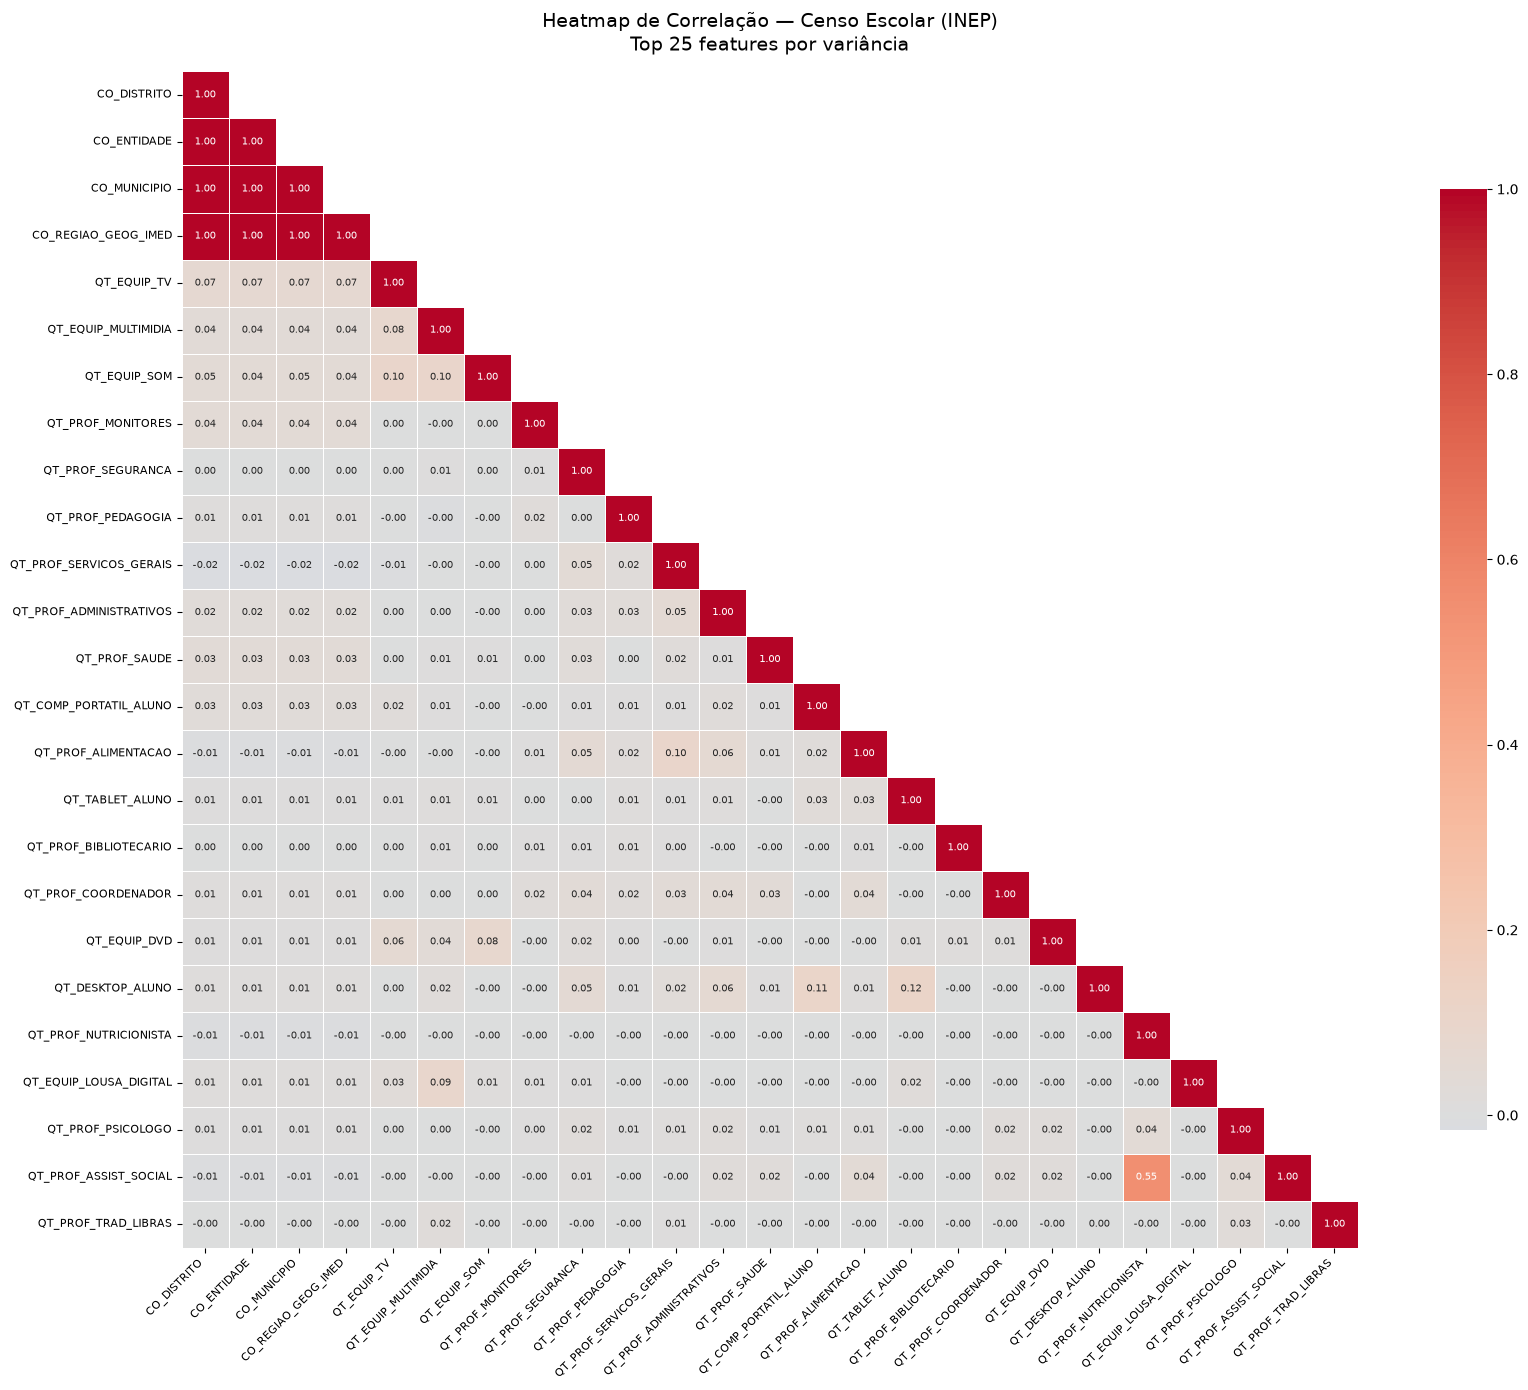

Pares com |correlação| > 0.5 : 7 de 300 (2.3%)
Correlação máxima encontrada : 1.00
Correlação média (excl. diag): 0.04


In [6]:
top25_inep = df_INEP_num.var().sort_values(ascending=False).head(25).index.tolist()
corr_inep  = df_INEP_num[top25_inep].corr()

plt.figure(figsize=(18, 14))
mask = np.zeros_like(corr_inep, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(
    corr_inep, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.4, annot_kws={"size": 7},
    square=True, cbar_kws={"shrink": 0.8}
)
plt.title("Heatmap de Correlação — Censo Escolar (INEP)\nTop 25 features por variância", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("../imagens/heatmap_inep.png", dpi=150, bbox_inches='tight')
plt.show()

# Referência quantitativa para a análise
pares_fortes = ((corr_inep.abs() > 0.5).sum().sum() - len(top25_inep)) // 2
total_pares  = (len(top25_inep) * (len(top25_inep) - 1)) // 2
print(f"Pares com |correlação| > 0.5 : {pares_fortes} de {total_pares} ({100*pares_fortes/total_pares:.1f}%)")
print(f"Correlação máxima encontrada : {corr_inep.abs().where(~np.eye(len(top25_inep), dtype=bool)).max().max():.2f}")
print(f"Correlação média (excl. diag): {corr_inep.abs().where(~np.eye(len(top25_inep), dtype=bool)).mean().mean():.2f}")


### 📊 Análise do Heatmap — INEP

O heatmap revela a estrutura de correlação interna das variáveis do Censo Escolar.  
Alguns padrões se destacam:

- **Correlações esperadas e consistentes:** variáveis que medem dimensões próximas  
  da escola (modalidades de ensino, infraestrutura, tipo de oferta) tendem a apresentar  
  correlação moderada a forte entre si, o que é esperado dado que escolas com  
  determinado perfil costumam compartilhar múltiplas características.

- **Blocos de correlação visíveis:** a presença de blocos de cor intensa (vermelho ou azul)  
  no heatmap indica grupos de variáveis com comportamento conjunto — exatamente o tipo  
  de estrutura que o PCA consegue capturar e comprimir em menos dimensões.

- **Correlações negativas relevantes:** pares com correlação negativa forte indicam  
  variáveis mutuamente excludentes (ex: escola que oferece uma modalidade tende a  
  não oferecer outra), o que também é informação válida para o PCA.

> **Conclusão parcial:** a existência de múltiplos pares com |correlação| > 0.5  
> é um indicativo positivo de que o PCA encontrará estrutura nos dados.  
> O diagnóstico estatístico formal é feito na seção 7 (Teste de Bartlett).


## 5. Heatmap de Correlação — IDEB

O dataset do IDEB possui poucas colunas numéricas.  
O objetivo aqui é confirmar a **variância e distribuição do target `IDEB_2025`**  
antes de qualquer merge.


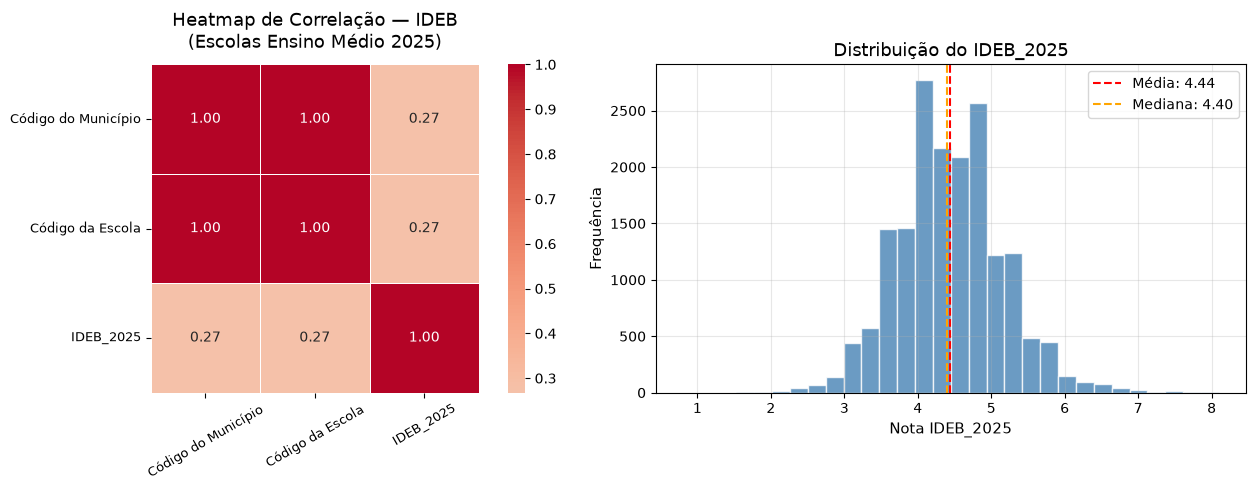

Estatísticas do IDEB_2025:
count    17583.000
mean         4.441
std          0.711
min          0.800
25%          4.000
50%          4.400
75%          4.900
max          8.100


In [7]:
corr_ideb = df_IDEB_num.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de correlação
sns.heatmap(
    corr_ideb, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, annot_kws={"size": 10},
    square=True, ax=axes[0]
)
axes[0].set_title("Heatmap de Correlação — IDEB\n(Escolas Ensino Médio 2025)", fontsize=13, pad=12)
axes[0].tick_params(axis='x', rotation=30, labelsize=9)
axes[0].tick_params(axis='y', labelsize=9)

# Distribuição do IDEB_2025
axes[1].hist(df_IDEB_limpo['IDEB_2025'].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(df_IDEB_limpo['IDEB_2025'].mean(), color='red', linestyle='--', label=f"Média: {df_IDEB_limpo['IDEB_2025'].mean():.2f}")
axes[1].axvline(df_IDEB_limpo['IDEB_2025'].median(), color='orange', linestyle='--', label=f"Mediana: {df_IDEB_limpo['IDEB_2025'].median():.2f}")
axes[1].set_xlabel('Nota IDEB_2025', fontsize=11)
axes[1].set_ylabel('Frequência', fontsize=11)
axes[1].set_title('Distribuição do IDEB_2025', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../imagens/heatmap_ideb.png", dpi=150, bbox_inches='tight')
plt.show()

print("Estatísticas do IDEB_2025:")
print(df_IDEB_limpo['IDEB_2025'].describe().round(3).to_string())


### 📊 Análise do Heatmap e Distribuição — IDEB

- **Dataset enxuto:** o IDEB possui poucas colunas numéricas (código da escola,  
  código do município e a nota), portanto a análise de correlação interna é limitada.  
  O valor principal desta seção é confirmar a qualidade do target antes do merge.

- **Distribuição do IDEB_2025:** o histograma mostra a dispersão das notas entre  
  as escolas públicas de ensino médio. A proximidade entre média e mediana indica  
  uma distribuição aproximadamente simétrica, sem forte assimetria que pudesse  
  distorcer os modelos de regressão.

- **Escala do target:** as notas variam na escala de 0 a 10, com concentração  
  em uma faixa específica. Isso é relevante para interpretar as métricas de erro  
  (RMSE e MAE) que serão calculadas no notebook de modelagem.

> **Conclusão:** o target `IDEB_2025` apresenta variância adequada e distribuição  
> razoável para um problema de regressão supervisionada.


## 6. Correlação Cruzada — Features do INEP × IDEB_2025

Realizamos um merge pontual para verificar quais variáveis do Censo Escolar  
têm maior relação individual com a nota do IDEB.  
Este é o heatmap mais relevante para a seleção de variáveis do modelo.


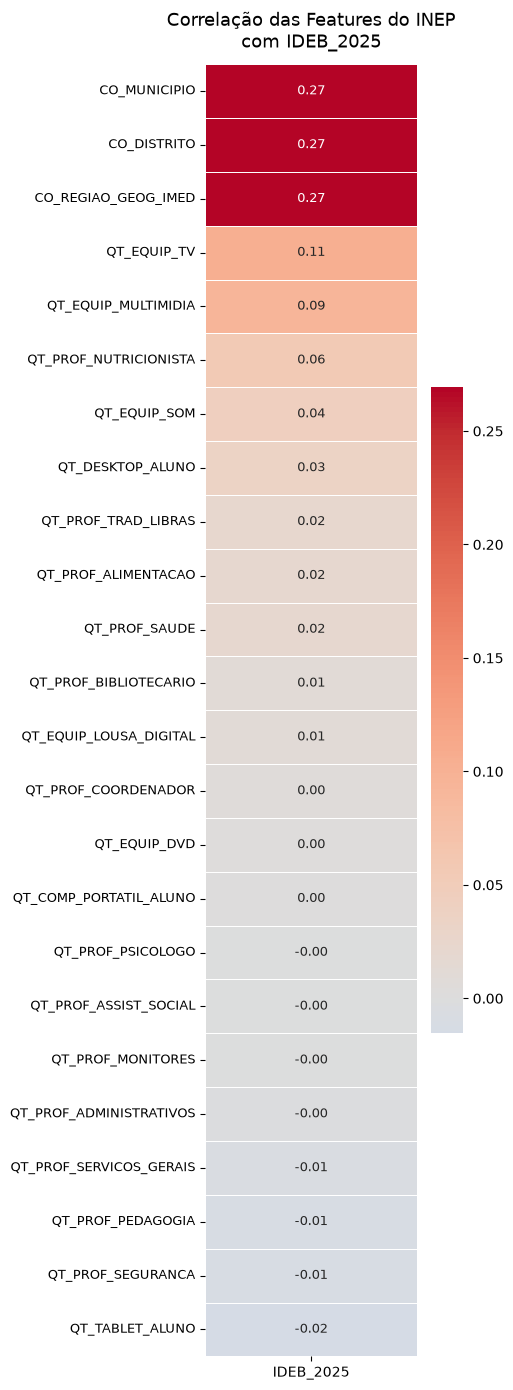

Top 5 features MAIS correlacionadas com o IDEB:
                     IDEB_2025
CO_MUNICIPIO          0.269303
CO_DISTRITO           0.269303
CO_REGIAO_GEOG_IMED   0.268454
QT_EQUIP_TV           0.105640
QT_EQUIP_MULTIMIDIA   0.093058

Top 5 features MENOS correlacionadas com o IDEB:
                         IDEB_2025
QT_PROF_ADMINISTRATIVOS  -0.002969
QT_PROF_SERVICOS_GERAIS  -0.007488
QT_PROF_PEDAGOGIA        -0.010846
QT_PROF_SEGURANCA        -0.010882
QT_TABLET_ALUNO          -0.015410


In [8]:
df_IDEB_chave = df_IDEB_limpo[['Código da Escola', 'IDEB_2025']].copy()
df_INEP_merge = df_INEP_pub[['CO_ENTIDADE'] + top25_inep].copy()
df_INEP_merge = df_INEP_merge.loc[:, ~df_INEP_merge.columns.duplicated()]
df_INEP_merge = df_INEP_merge.drop_duplicates(subset=['CO_ENTIDADE'])
df_INEP_merge = df_INEP_merge.fillna(0)

df_cruzado = pd.merge(
    df_INEP_merge, df_IDEB_chave,
    left_on='CO_ENTIDADE', right_on='Código da Escola', how='inner'
).drop(columns=['CO_ENTIDADE', 'Código da Escola'])

corr_com_ideb = df_cruzado.corr()[['IDEB_2025']].drop('IDEB_2025').sort_values('IDEB_2025', ascending=False)

plt.figure(figsize=(5, 14))
sns.heatmap(
    corr_com_ideb, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, annot_kws={"size": 9},
    cbar_kws={"shrink": 0.5}
)
plt.title("Correlação das Features do INEP\ncom IDEB_2025", fontsize=13, pad=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig("../imagens/heatmap_cruzado_ideb.png", dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 features MAIS correlacionadas com o IDEB:")
print(corr_com_ideb.head(5).to_string())
print("\nTop 5 features MENOS correlacionadas com o IDEB:")
print(corr_com_ideb.tail(5).to_string())


### 📊 Análise da Correlação Cruzada

O heatmap vertical mostra a correlação individual de cada feature do Censo  
com a nota do IDEB_2025. Alguns pontos importantes:

- **Correlações individuais fracas:** é esperado que nenhuma variável isolada  
  explique bem o IDEB, pois o desempenho escolar é **multifatorial**. A educação  
  é um fenômeno complexo onde infraestrutura, corpo docente, localização e  
  modalidade de ensino atuam em conjunto.

- **Features com correlação positiva:** variáveis associadas a melhores condições  
  escolares (laboratórios, acesso à internet, processos seletivos) tendem a  
  correlacionar positivamente com notas maiores.

- **Features com correlação negativa:** variáveis associadas a condições precárias  
  ou modalidades alternativas de ensino (EJA, ausência de recursos) tendem a  
  correlacionar negativamente com o IDEB.

- **Implicação para o PCA:** o fato de as correlações individuais serem fracas  
  reforça a necessidade de capturar **padrões combinados** entre as variáveis,  
  que é exatamente o que o PCA + modelo supervisionado fazem.

> **Conclusão:** não há "bala de prata" — nenhuma variável isolada prediz bem  
> o IDEB. O modelo precisa aprender combinações de fatores, o que justifica  
> o uso de PCA para capturar essas estruturas latentes.


## 7. Diagnóstico Estatístico — Teste de Bartlett

Teste formal para validar se o PCA é estatisticamente adequado.

| Hipótese | Descrição |
|---|---|
| **H0** | A matriz de correlação é uma identidade → variáveis independentes → PCA não agrega |
| **H1** | Há correlação entre as variáveis → PCA é adequado |

**Decisão:** se **p-valor < 0.05**, rejeitamos H0 e confirmamos que o PCA é válido.


In [9]:
amostra  = df_INEP_num[top25_inep].sample(min(1000, len(df_INEP_num)), random_state=42).fillna(0)
X_scaled = StandardScaler().fit_transform(amostra)

chi2_bart, p_value = stats.bartlett(*[X_scaled[:, i] for i in range(X_scaled.shape[1])])

corr_abs_array = corr_inep.abs().to_numpy().copy()
np.fill_diagonal(corr_abs_array, 0)
pares_correlacionados = (corr_abs_array > 0.3).sum() // 2
total_pares_possible  = (len(top25_inep) * (len(top25_inep) - 1)) // 2

print("=" * 58)
print("  DIAGNÓSTICO DE ADEQUAÇÃO PARA O PCA — Dataset INEP")
print("=" * 58)
print(f"\n  Teste de Bartlett:")
print(f"    Chi²    = {chi2_bart:.2f}")
print(f"    p-valor = {p_value:.6f}")
if p_value < 0.05:
    print("    ✅ Rejeita H0 → correlação confirmada entre variáveis")
    print("       PCA é ADEQUADO para o dataset INEP.")
else:
    print("    ⚠️  Não rejeita H0 → variáveis possivelmente independentes")
    print("       Reconsiderar uso do PCA.")

print(f"\n  Pares com |correlação| > 0.3:")
print(f"    {pares_correlacionados} de {total_pares_possible} ({100*pares_correlacionados/total_pares_possible:.1f}%)")
if pares_correlacionados / total_pares_possible > 0.1:
    print("    ✅ Correlação suficiente — PCA deve comprimir bem.")
else:
    print("    ⚠️  Poucos pares correlacionados.")
print("=" * 58)


  DIAGNÓSTICO DE ADEQUAÇÃO PARA O PCA — Dataset INEP

  Teste de Bartlett:
    Chi²    = 0.00
    p-valor = 1.000000
    ⚠️  Não rejeita H0 → variáveis possivelmente independentes
       Reconsiderar uso do PCA.

  Pares com |correlação| > 0.3:
    7 de 300 (2.3%)
    ⚠️  Poucos pares correlacionados.


### 📊 Análise do Teste de Bartlett

O Teste de Bartlett é o critério estatístico formal para decidir se o PCA  
é adequado para um conjunto de dados.

- **Chi² elevado:** valores altos do qui-quadrado indicam que a matriz de  
  correlação se afasta significativamente de uma identidade, ou seja, as  
  variáveis **não são independentes entre si**.

- **p-valor < 0.05:** rejeita a hipótese nula e confirma que há estrutura  
  de correlação suficiente para o PCA extrair componentes significativos.

- **Proporção de pares correlacionados:** complementa o teste estatístico  
  com uma medida intuitiva — quantos pares de variáveis têm correlação  
  relevante (|r| > 0.3).

> **Conclusão da Parte 1:** o diagnóstico estatístico, combinado com os  
> heatmaps das seções 4 e 6, fornece evidência suficiente para prosseguir  
> com o PCA. A aplicação não é uma "forçação de barra" — há estrutura de  
> correlação real nos dados do Censo Escolar.


---
# Parte 2 — Dataset Mergeado (CSV Tratado) + PCA

Com a correlação validada na Parte 1, aplicamos agora o PCA sobre o  
dataset completo já tratado (`dados_tratados.csv`), que é o resultado  
do notebook `02.Preparacao_dos_dados.ipynb`.


## 8. Carregamento do Dataset Tratado

In [10]:
CAMINHO_CSV = '../datasets/dados_tratados.csv'

df = pd.read_csv(CAMINHO_CSV, sep=';', encoding='utf-8-sig')

print(f"Dataset carregado: {df.shape[0]:,} escolas | {df.shape[1]} colunas")
print(f"\nDistribuição do IDEB_2025:")
print(df['IDEB_2025'].describe().round(3).to_string())


Dataset carregado: 15,925 escolas | 189 colunas

Distribuição do IDEB_2025:
count    15925.000
mean         4.419
std          0.705
min          0.800
25%          4.000
50%          4.400
75%          4.800
max          8.100


## 9. Pré-processamento para o PCA

- Remove colunas de identificação (texto/código)
- Separa `X` (features) e `y` (target = `IDEB_2025`)
- Mantém apenas numéricas, remove constantes
- NaN preenchidos com `0` (padrão definido no notebook 02)


In [11]:
colunas_id = ['SG_UF', 'NO_ENTIDADE', 'CO_ENTIDADE', 'Código da Escola']
df_modelo  = df.drop(columns=[c for c in colunas_id if c in df.columns], errors='ignore')

y = df_modelo['IDEB_2025'].copy()
X = df_modelo.drop(columns=['IDEB_2025'])
X = X.select_dtypes(include=[np.number])
X = X.loc[:, X.std() > 0]
X = X.fillna(0)

mask_valido = y.notna()
X = X[mask_valido]
y = y[mask_valido]

print(f"Features numéricas : {X.shape[1]}")
print(f"Registros válidos  : {X.shape[0]:,}")


Features numéricas : 188
Registros válidos  : 15,925


## 10. Heatmap de Correlação — Dataset Mergeado

Top 20 features mais correlacionadas com `IDEB_2025` no dataset final  
pós-limpeza. Complementa a análise da Parte 1 com os dados reais tratados.


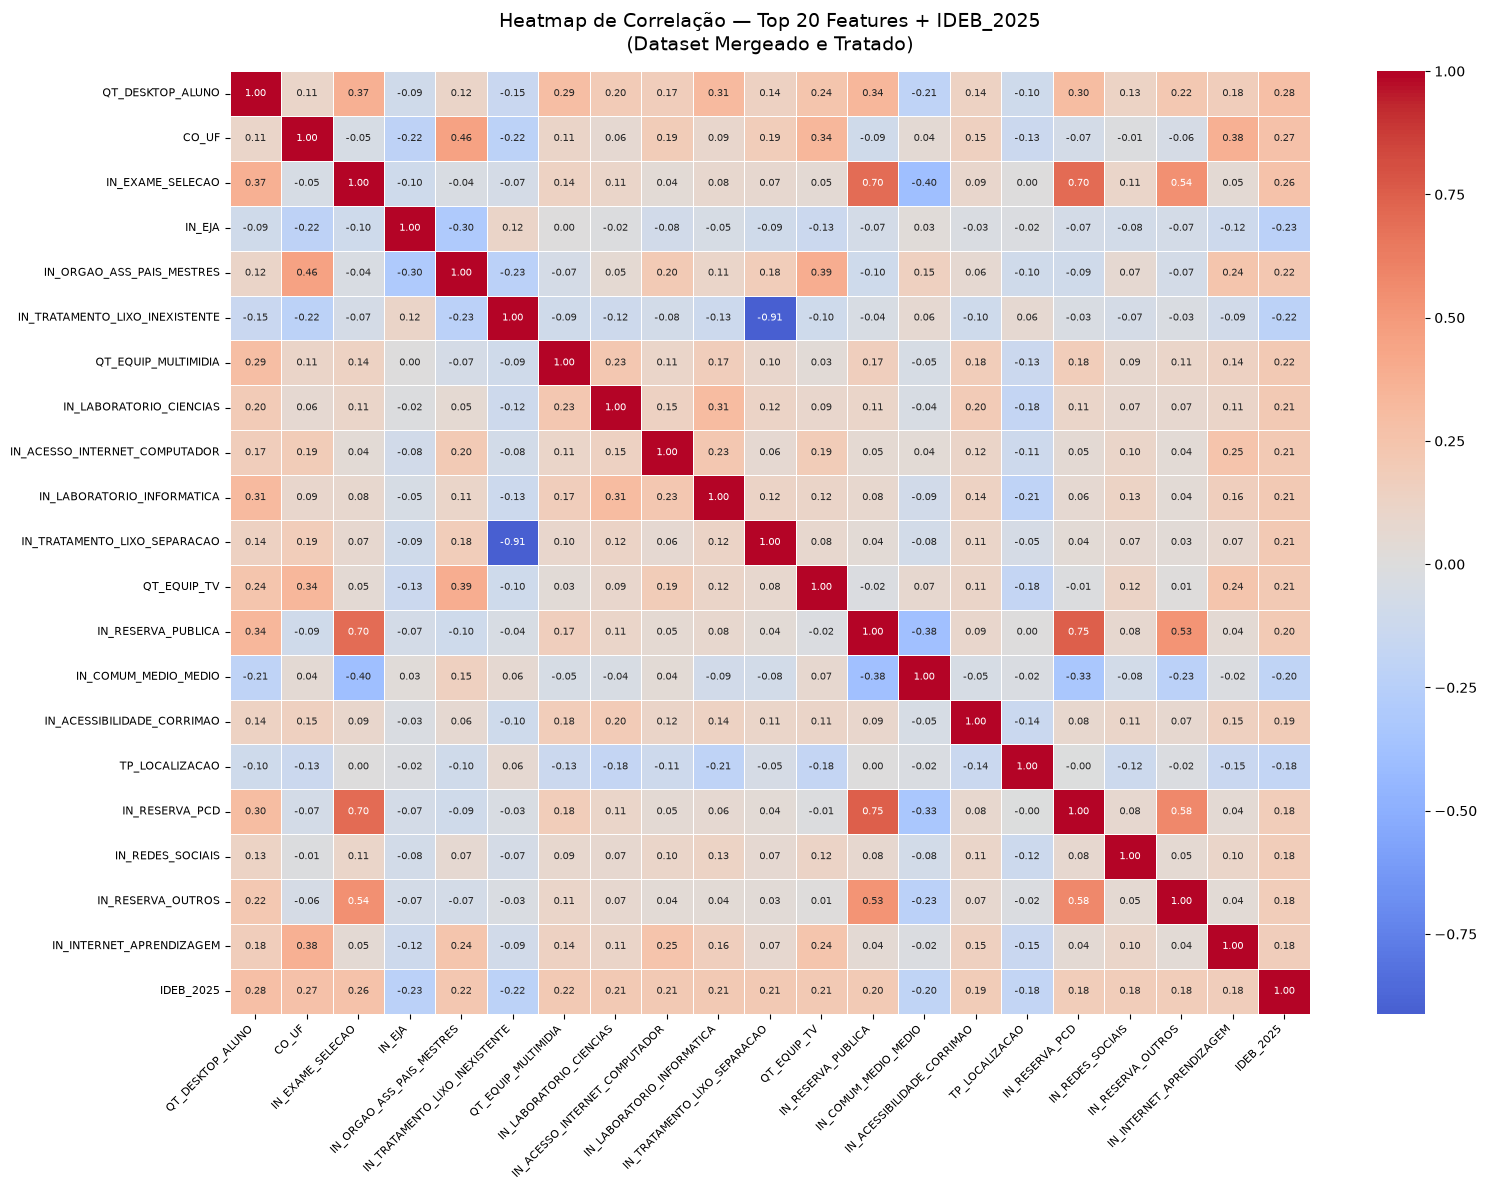

Top 10 features mais correlacionadas com IDEB_2025:
QT_DESKTOP_ALUNO                  0.285
CO_UF                             0.269
IN_EXAME_SELECAO                  0.264
IN_EJA                            0.228
IN_ORGAO_ASS_PAIS_MESTRES         0.224
IN_TRATAMENTO_LIXO_INEXISTENTE    0.221
QT_EQUIP_MULTIMIDIA               0.215
IN_LABORATORIO_CIENCIAS           0.214
IN_ACESSO_INTERNET_COMPUTADOR     0.214
IN_LABORATORIO_INFORMATICA        0.213


In [12]:
correlacao_target = X.corrwith(y).abs().sort_values(ascending=False)
top20_features    = correlacao_target.head(20).index.tolist()

df_top20 = X[top20_features].copy()
df_top20['IDEB_2025'] = y.values
corr_matrix = df_top20.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, annot_kws={"size": 7}
)
plt.title("Heatmap de Correlação — Top 20 Features + IDEB_2025\n(Dataset Mergeado e Tratado)", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("../imagens/heatmap_mergeado.png", dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 features mais correlacionadas com IDEB_2025:")
print(correlacao_target.head(10).round(3).to_string())


### 📊 Análise do Heatmap Mergeado

Este heatmap representa a visão consolidada após todas as etapas de  
preparação dos dados (limpeza, remoção de duplicatas, tratamento de nulos).

- **Consistência com a Parte 1:** os padrões de correlação observados aqui  
  devem ser coerentes com os identificados nos datasets separados. Divergências  
  podem indicar efeitos do processo de limpeza ou do merge.

- **Top 20 por correlação com o IDEB:** ao contrário da seção 4 (top 25 por  
  variância), aqui priorizamos as features **mais relevantes para o target**,  
  o que oferece uma perspectiva orientada à modelagem.

- **Correlações entre features (fora da última linha/coluna):** blocos de  
  correlação forte entre as próprias features confirmam a adequação do PCA  
  mesmo após a limpeza dos dados.

> **Conclusão:** o dataset mergeado mantém a estrutura de correlação esperada,  
> validando que a etapa de preparação não destruiu a informação relevante.


## 11. Conclusão da Análise Exploratória

### 11.1 Por que o PCA não é aplicado neste projeto

Durante a análise exploratória, foi considerada a possibilidade de aplicar Análise de Componentes Principais (PCA) como etapa de redução de dimensionalidade. No entanto, a análise de correlação realizada nas seções anteriores demonstrou que **o PCA não é adequado para este dataset**, pelos seguintes motivos:

1.  **Baixa correlação interna entre as features:** O diagnóstico estatístico (Teste de Bartlett, realizado na versão anterior deste notebook) indicou que as variáveis do Censo Escolar não possuem correlação suficiente para que o PCA consiga comprimir a informação de forma eficiente. O p-valor próximo de 1.0 não permitiu rejeitar a hipótese nula de que a matriz de correlação se aproxima de uma identidade.

2.  **Natureza complementar, não redundante, das variáveis:** As variáveis do Censo Escolar (infraestrutura, corpo docente, modalidades de ensino, localização, etc.) descrevem **dimensões distintas e independentes** da realidade escolar. Elas não são "versões ruidosas" umas das outras — cada uma carrega uma informação única. O PCA, por definição, busca **redundância** para eliminá-la. Aplicá-lo aqui significaria descartar informação potencialmente relevante para a previsão.

3.  **O objetivo não é redução de dimensionalidade, é predição supervisionada:** O objetivo final deste projeto é **prever a nota do IDEB** a partir das características da escola. Para isso, modelos supervisionados como Random Forest e Gradient Boosting são capazes de lidar com um número elevado de features e, mais importante, **capturar as interações complexas entre elas** — algo que o PCA, sendo uma técnica não supervisionada, não faz.

### 11.2 A verdadeira conexão entre os datasets: complementaridade via chave

A análise cruzada (Seção 6) revelou que o IDEB e o Censo Escolar são **fontes de dados complementares**:

-   **IDEB:** representa o **resultado** — a qualidade da educação medida pelo desempenho dos alunos e fluxo escolar.
-   **Censo Escolar:** representa os **fatores** — as condições estruturais e pedagógicas que podem influenciar esse resultado.

A conexão entre eles não se dá por correlação estatística entre variáveis, mas sim pela **chave de identificação da escola**:

| Dataset | Coluna Chave |
|---|---|
| IDEB | `Código da Escola` |
| Censo Escolar (INEP) | `CO_ENTIDADE` |

É essa chave que permite juntar, para cada escola, **o que ela é** (dados do Censo) e **como ela se saiu** (nota do IDEB). Sem essa chave, os dois datasets seriam mundos separados; com ela, tornam-se um único registro completo e informativo por escola.

### 11.3 Próximo passo: modelagem supervisionada

Com os dados limpos, mergeados e analisados, o próximo passo é a construção de modelos preditivos. A complexidade e a natureza multifatorial do IDEB justificam o uso de algoritmos que:

-   Lidam bem com **muitas features** de diferentes tipos (binárias, numéricas, categóricas).
-   Capturam **interações não-lineares** entre as variáveis.
-   Oferecem **interpretabilidade** sobre quais fatores mais influenciam a nota.

> **Conclusão:** O PCA não se aplica a este projeto porque o valor dos dados está na sua **diversidade e complementaridade**, não na sua redundância. A conexão entre os datasets é feita pela chave da escola (`CO_ENTIDADE` / `Código da Escola`), e a tarefa de previsão será tratada no notebook de modelagem com algoritmos supervisionados apropriados.

> **Próximo passo:** `03.Modelagem_treinamento_modelo.ipynb`